# SCRATCH IMPLEMENTATION --

In [ ]:
import numpy as np

def step_activation(weighted_sum):
    return 1 if weighted_sum >= 0 else 0

def perceptron(x1, x2, w1, w2, bias):
    weighted_sum = (x1 * w1) + (x2 * w2) + bias
    return step_activation(weighted_sum)

and_gate_data = [
    ([0, 0], 0),
    ([0, 1], 0),
    ([1, 0], 0),
    ([1, 1], 1)
]


In [ ]:
def train_perceptron(initial_weights, initial_bias, learning_rate, epochs, training_data):
    w1, w2 = initial_weights
    bias = initial_bias

    print("\nStarting Perceptron Training...")
    print(f"Initial Weights: w1={w1}, w2={w2}, Bias={bias}")

    for epoch in range(epochs):
        total_error = 0
        for inputs, expected_output in training_data:
            x1, x2 = inputs

            weighted_sum = (x1 * w1) + (x2 * w2) + bias
            predicted_output = step_activation(weighted_sum)
            error = expected_output - predicted_output

            if error != 0:
                w1 = w1 + learning_rate * error * x1
                w2 = w2 + learning_rate * error * x2
                bias = bias + learning_rate * error
                total_error += 1

        print(f"Epoch {epoch + 1}: Total Error = {total_error}, Updated Weights: w1={w1:.2f}, w2={w2:.2f}, Bias={bias:.2f}")

        if total_error == 0:
            print(f"Perceptron converged after {epoch + 1} epochs!")
            break

    print("Training Complete.")
    return w1, w2, bias

In [ ]:
initial_weights = [0.5, 0.5]
initial_bias = -0.75
learning_rate = 0.1
epochs = 100

trained_w1, trained_w2, trained_bias = train_perceptron(initial_weights, initial_bias, learning_rate, epochs, and_gate_data)

print(f"\nFinal Learned Weights: w1={trained_w1:.2f}, w2={trained_w2:.2f}, Bias={trained_bias:.2f}")

print("\nTesting Trained Perceptron for AND Gate:")
test_results = []
for (x1, x2), expected_output in and_gate_data:
    output = perceptron(x1, x2, trained_w1, trained_w2, trained_bias)
    is_correct = "Correct" if output == expected_output else "Incorrect"
    test_results.append(f"Input: ({x1}, {x2}), Predicted: {output}, Expected: {expected_output} -> {is_correct}")

for res in test_results:
    print(res)


Starting Perceptron Training...
Initial Weights: w1=0.5, w2=0.5, Bias=-0.75
Epoch 1: Total Error = 0, Updated Weights: w1=0.50, w2=0.50, Bias=-0.75
Perceptron converged after 1 epochs!
Training Complete.

Final Learned Weights: w1=0.50, w2=0.50, Bias=-0.75

Testing Trained Perceptron for AND Gate:
Input: (0, 0), Predicted: 0, Expected: 0 -> Correct
Input: (0, 1), Predicted: 0, Expected: 0 -> Correct
Input: (1, 0), Predicted: 0, Expected: 0 -> Correct
Input: (1, 1), Predicted: 1, Expected: 1 -> Correct


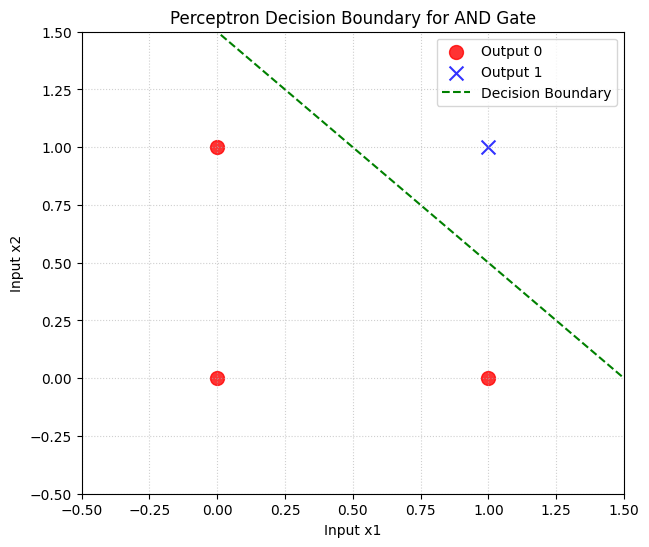

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x1_coords = [point[0][0] for point in and_gate_data]
x2_coords = [point[0][1] for point in and_gate_data]
outputs = [point[1] for point in and_gate_data]

plt.figure(figsize=(7, 6))

for i in range(len(x1_coords)):
    if outputs[i] == 0:
        plt.scatter(x1_coords[i], x2_coords[i], color='red', marker='o', s=100, label='Output 0' if i == 0 else "", alpha=0.8)
    else:
        plt.scatter(x1_coords[i], x2_coords[i], color='blue', marker='x', s=100, label='Output 1' if i == 3 else "", alpha=0.8)

if trained_w2 != 0:
    x_boundary = np.linspace(-0.5, 1.5, 100)
    y_boundary = -(trained_w1 * x_boundary + trained_bias) / trained_w2
    plt.plot(x_boundary, y_boundary, color='green', linestyle='--', label='Decision Boundary')
elif trained_w1 != 0:
    x_boundary_val = -trained_bias / trained_w1
    plt.axvline(x=x_boundary_val, color='green', linestyle='--', label='Decision Boundary')
else:
    pass

plt.title('Perceptron Decision Boundary for AND Gate')
plt.xlabel('Input x1')
plt.ylabel('Input x2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# SKLEARN IMPLEMENTATION --

In [ ]:
X_list = []
y_list = []

for inputs, expected_output in and_gate_data:
    X_list.append(inputs)
    y_list.append(expected_output)

X = np.array(X_list)
y = np.array(y_list)

print(f"Features (X) shape: {X.shape}\n{X}")
print(f"Labels (y) shape: {y.shape}\n{y}")

Features (X) shape: (4, 2)
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Labels (y) shape: (4,)
[0 0 0 1]


In [ ]:
from sklearn.linear_model import Perceptron

perceptron_skl = Perceptron(random_state=0)

perceptron_skl.fit(X, y)

print("Scikit-learn Perceptron model trained successfully.")

Scikit-learn Perceptron model trained successfully.


In [ ]:
learned_weights = perceptron_skl.coef_
learned_bias = perceptron_skl.intercept_

print(f"Learned Weights: {learned_weights[0]}")
print(f"Learned Bias: {learned_bias[0]}")

Learned Weights: [2. 2.]
Learned Bias: -2.0


In [ ]:
predictions = perceptron_skl.predict(X)

print("\nTesting Scikit-learn Perceptron for AND Gate:")
for i in range(len(X)):
    input_data = X[i]
    expected = y[i]
    predicted = predictions[i]
    is_correct = "Correct" if predicted == expected else "Incorrect"
    print(f"Input: {input_data}, Predicted: {predicted}, Expected: {expected} -> {is_correct}")


Testing Scikit-learn Perceptron for AND Gate:
Input: [0 0], Predicted: 0, Expected: 0 -> Correct
Input: [0 1], Predicted: 0, Expected: 0 -> Correct
Input: [1 0], Predicted: 0, Expected: 0 -> Correct
Input: [1 1], Predicted: 1, Expected: 1 -> Correct


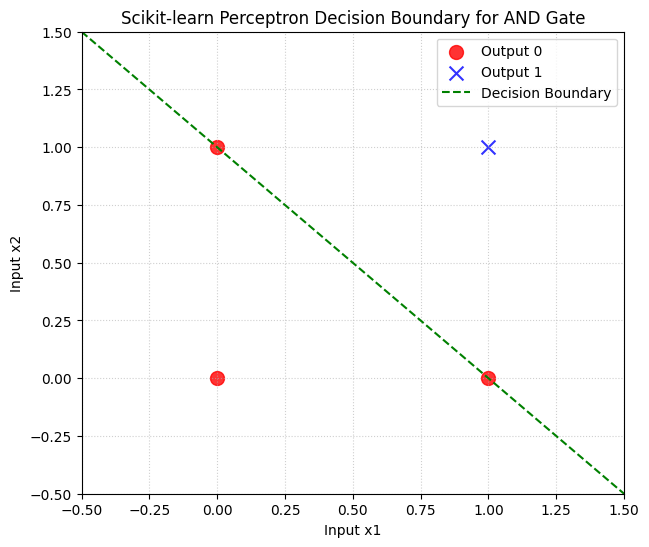

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', s=100, label='Output 0', alpha=0.8)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', s=100, label='Output 1', alpha=0.8)

w1, w2 = learned_weights[0]
bias = learned_bias[0]

if w2 != 0:
    x_boundary = np.linspace(-0.5, 1.5, 100)
    y_boundary = -(w1 * x_boundary + bias) / w2
    plt.plot(x_boundary, y_boundary, color='green', linestyle='--', label='Decision Boundary')
elif w1 != 0:
    x_boundary_val = -bias / w1
    plt.axvline(x=x_boundary_val, color='green', linestyle='--', label='Decision Boundary')
else:
    pass

plt.title('Scikit-learn Perceptron Decision Boundary for AND Gate')
plt.xlabel('Input x1')
plt.ylabel('Input x2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()